In [21]:
# === Risk Factor Analyst (роль 2) — Шаг 0: загрузка и проверка данных ===
import numpy as np
import pandas as pd

# воспроизводимость на весь ноутбук
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Вход — итоговая таблица участника №1
df = pd.read_csv("data/data_clean.csv", index_col=0, parse_dates=True)
df.index.name = "DATE"
df = df.sort_index()

# Разбивка колонок по группам (определяем риск-факторные блоки)
rate_cols  = [c for c in df.columns if c.startswith("ZCYC_")]
ofz_cols   = [c for c in df.columns if c.startswith("OFZ_")]
stk_cols   = [c for c in df.columns if c.startswith("STK_")]
idx_cols   = [c for c in df.columns if c.startswith("IDX_")]
fx_cols    = [c for c in df.columns if c.startswith("FX_")]
brent_cols = [c for c in df.columns if c == "BRENT"]

print("Форма:", df.shape)
print("Период:", df.index.min().date(), "→", df.index.max().date())
print("Дубликатов дат:", df.index.duplicated().sum())
print("Всего пропусков:", int(df.isna().sum().sum()))
print()
print(f"Ставки КБД ({len(rate_cols)}): {rate_cols}")
print(f"ОФЗ ({len(ofz_cols)}):        {ofz_cols}")
print(f"Акции ({len(stk_cols)}):      {stk_cols}")
print(f"Индексы ({len(idx_cols)}):    {idx_cols}")
print(f"Валюты ({len(fx_cols)}):      {fx_cols}")
print(f"Brent ({len(brent_cols)}):    {brent_cols}")
print()
print("Типы данных (уникальные):", df.dtypes.unique())
print("\nПервые/последние даты:")
print(df.index[:3].tolist(), "...", df.index[-3:].tolist())
display(df.head(3))
display(df.describe().T[["mean","std","min","max"]].round(2))

Форма: (1271, 32)
Период: 2021-01-04 → 2025-12-30
Дубликатов дат: 0
Всего пропусков: 0

Ставки КБД (12): ['ZCYC_0.25y', 'ZCYC_0.5y', 'ZCYC_0.75y', 'ZCYC_1.0y', 'ZCYC_2.0y', 'ZCYC_3.0y', 'ZCYC_5.0y', 'ZCYC_7.0y', 'ZCYC_10.0y', 'ZCYC_15.0y', 'ZCYC_20.0y', 'ZCYC_30.0y']
ОФЗ (5):        ['OFZ_26219', 'OFZ_26212', 'OFZ_26221', 'OFZ_26218', 'OFZ_26230']
Акции (10):      ['STK_SBER', 'STK_GAZP', 'STK_LKOH', 'STK_GMKN', 'STK_ROSN', 'STK_NVTK', 'STK_TATN', 'STK_MGNT', 'STK_MTSS', 'STK_CHMF']
Индексы (2):    ['IDX_IMOEX', 'IDX_RTSI']
Валюты (2):      ['FX_USD', 'FX_EUR']
Brent (1):    ['BRENT']

Типы данных (уникальные): [dtype('float64')]

Первые/последние даты:
[Timestamp('2021-01-04 00:00:00'), Timestamp('2021-01-05 00:00:00'), Timestamp('2021-01-06 00:00:00')] ... [Timestamp('2025-12-26 00:00:00'), Timestamp('2025-12-29 00:00:00'), Timestamp('2025-12-30 00:00:00')]


,ZCYC_0.25y,ZCYC_0.5y,ZCYC_0.75y,ZCYC_1.0y,ZCYC_2.0y,ZCYC_3.0y,ZCYC_5.0y,ZCYC_7.0y,ZCYC_10.0y,ZCYC_15.0y,...,STK_NVTK,STK_TATN,STK_MGNT,STK_MTSS,STK_CHMF,IDX_IMOEX,IDX_RTSI,FX_USD,FX_EUR,BRENT
DATE,,,,,,,,,,,,,,,,,,,,,
2021-01-04,4.03,4.09,4.14,4.20,4.50,4.87,5.44,5.84,6.25,6.65,...,1250.4,515.8,5744.0,334.90,1343.2,3350.51,1424.84,74.5157,90.8123,51.54
2021-01-05,3.98,4.04,4.11,4.18,4.48,4.82,5.38,5.80,6.22,6.62,...,1287.4,524.2,5762.5,337.80,1334.2,3359.15,1426.11,74.5157,90.8123,52.87
2021-01-06,3.85,3.95,4.04,4.11,4.42,4.79,5.40,5.83,6.24,6.62,...,1301.2,522.0,5534.0,334.05,1326.4,3371.03,1436.71,74.5157,90.8123,54.33


,mean,std,min,max
ZCYC_0.25y,11.77,5.15,3.78,23.62
ZCYC_0.5y,11.66,4.95,3.88,23.36
ZCYC_0.75y,11.61,4.81,3.99,23.07
ZCYC_1.0y,11.58,4.69,4.08,22.78
ZCYC_2.0y,11.55,4.31,4.42,21.55
ZCYC_3.0y,11.55,3.99,4.79,20.71
ZCYC_5.0y,11.58,3.54,5.38,19.26
ZCYC_7.0y,11.61,3.26,5.80,18.08
ZCYC_10.0y,11.62,3.02,6.22,16.89
ZCYC_15.0y,11.63,2.83,6.59,16.29


In [22]:
# === Шаг 1: преобразование сырых рядов в риск-факторные приращения ===
# Логика выбора преобразований:
#   - Ставки КБД: процентный риск моделируем через ИЗМЕНЕНИЯ кривой (б.п./день),
#     т.к. уровни нестационарны, а изменения ~ стационарны (проверим ADF позже).
#   - Акции / FX / Brent / индексы: ЛОГ-доходности (аддитивны, без масштаба цены).

# 1) Изменения ставок в базисных пунктах (rate в %, 1% = 100 б.п.)
rate_chg = df[rate_cols].diff() * 100.0
rate_chg.columns = [c.replace("ZCYC_", "dR_") for c in rate_cols]

# 2) Лог-доходности по ценовым рядам
def log_ret(frame):
    return np.log(frame / frame.shift(1))

stk_ret   = log_ret(df[stk_cols]);   stk_ret.columns   = [c.replace("STK_", "r_")   for c in stk_cols]
fx_ret    = log_ret(df[fx_cols]);    fx_ret.columns    = [c.replace("FX_", "r_")     for c in fx_cols]
brent_ret = log_ret(df[brent_cols]); brent_ret.columns = ["r_BRENT"]
idx_ret   = log_ret(df[idx_cols]);   idx_ret.columns   = [c.replace("IDX_", "r_")    for c in idx_cols]

# Объединяем все приращения, убираем первую строку (NaN от diff)
returns = pd.concat([rate_chg, stk_ret, fx_ret, brent_ret, idx_ret], axis=1).iloc[1:]

print("Матрица приращений:", returns.shape)
print("Пропусков:", int(returns.isna().sum().sum()))

# --- ДИАГНОСТИКА: экстремальные дневные движения по акциям/FX/Brent (|r|>40%) ---
ret_only = pd.concat([stk_ret, fx_ret, brent_ret], axis=1)
extreme = ret_only[(ret_only.abs() > 0.40)].stack().sort_values()
print("\nЭкстремальные дневные лог-доходности |r|>40% (кандидаты на сплит/ошибку):")
print(extreme.round(3) if len(extreme) else "нет")

# топ-5 по модулю движений GMKN, чтобы локализовать дату сплита
g = stk_ret["r_GMKN"].dropna()
print("\nТоп-5 |движений| GMKN:")
print(g.reindex(g.abs().sort_values(ascending=False).index).head(5).round(3))

Матрица приращений: (1270, 27)
Пропусков: 0

Экстремальные дневные лог-доходности |r|>40% (кандидаты на сплит/ошибку):
DATE              
2024-04-08  r_GMKN   -4.589
2022-02-24  r_SBER   -0.456
            r_ROSN   -0.451
dtype: float64

Топ-5 |движений| GMKN:
DATE
2024-04-08   -4.589
2022-02-24   -0.150
2022-02-21   -0.108
2022-03-21    0.097
2022-09-26   -0.096
Name: r_GMKN, dtype: float64


In [23]:
# === Шаг 1b: коррекция сплита GMKN (100:1, корпоративное действие, апрель 2024) ===
# Метод: back-adjustment — цены ДО даты сплита делим на коэффициент сплита,
# тогда уровень становится непрерывным, а ВСЕ доходности (включая день сплита)
# отражают только реальные рыночные движения.

SPLIT = {"STK_GMKN": {"date": pd.Timestamp("2024-04-08"), "factor": 100.0}}

df_adj = df.copy()
for col, info in SPLIT.items():
    pre = df_adj.index < info["date"]
    df_adj.loc[pre, col] = df_adj.loc[pre, col] / info["factor"]
    print(f"{col}: скорректировано {pre.sum()} дней до {info['date'].date()} "
          f"(делитель {info['factor']:.0f})")

# Пересчёт лог-доходностей GMKN на скорректированных ценах
gmkn_fixed = np.log(df_adj["STK_GMKN"] / df_adj["STK_GMKN"].shift(1)).iloc[1:]
returns["r_GMKN"] = gmkn_fixed

# --- Проверка: разрыв исчез, реальный день сплита стал нормальным ---
print("\nr_GMKN на 2024-04-08 после коррекции:", round(returns.loc['2024-04-08','r_GMKN'], 4))
print("Топ-5 |движений| GMKN после коррекции:")
g2 = returns["r_GMKN"]
print(g2.reindex(g2.abs().sort_values(ascending=False).index).head(5).round(3))

# Итоговая проверка матрицы факторов
print("\nИтоговая матрица приращений:", returns.shape, "| пропусков:", int(returns.isna().sum().sum()))
print("Колонки:", list(returns.columns))

STK_GMKN: скорректировано 827 дней до 2024-04-08 (делитель 100)

r_GMKN на 2024-04-08 после коррекции: 0.0159
Топ-5 |движений| GMKN после коррекции:
DATE
2022-02-24   -0.150
2022-02-21   -0.108
2022-03-21    0.097
2022-09-26   -0.096
2022-02-22    0.094
Name: r_GMKN, dtype: float64

Итоговая матрица приращений: (1270, 27) | пропусков: 0
Колонки: ['dR_0.25y', 'dR_0.5y', 'dR_0.75y', 'dR_1.0y', 'dR_2.0y', 'dR_3.0y', 'dR_5.0y', 'dR_7.0y', 'dR_10.0y', 'dR_15.0y', 'dR_20.0y', 'dR_30.0y', 'r_SBER', 'r_GAZP', 'r_LKOH', 'r_GMKN', 'r_ROSN', 'r_NVTK', 'r_TATN', 'r_MGNT', 'r_MTSS', 'r_CHMF', 'r_USD', 'r_EUR', 'r_BRENT', 'r_IMOEX', 'r_RTSI']


Доля объяснённой дисперсии по компонентам (ставки):
  PC1: 76.10%   накопл.  76.10%
  PC2: 13.09%   накопл.  89.19%
  PC3:  6.52%   накопл.  95.71%
  PC4:  3.27%   накопл.  98.98%
  PC5:  0.80%   накопл.  99.78%

Нагрузки PC1-3 по срокам:
       PC1_level  PC2_slope  PC3_curv
0.25y      0.433      0.431     0.415
0.5y       0.417      0.287     0.128
0.75y      0.399      0.170    -0.059
1.0y       0.380      0.075    -0.182
2.0y       0.318     -0.144    -0.356
3.0y       0.277     -0.231    -0.346
5.0y       0.232     -0.285    -0.229
7.0y       0.199     -0.302    -0.101
10.0y      0.156     -0.315     0.078
15.0y      0.124     -0.331     0.273
20.0y      0.113     -0.342     0.382
30.0y      0.106     -0.354     0.490


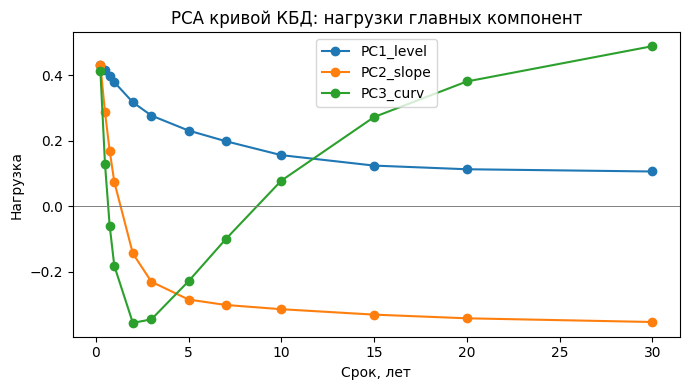

In [24]:
# === Шаг 2a: PCA на изменениях кривой КБД (б.п./день) ===
# Классика Litterman-Scheinkman: PCA по ковариации изменений ставок →
# PC1 = level (параллельный сдвиг), PC2 = slope (наклон), PC3 = curvature (изгиб).
import matplotlib.pyplot as plt
import sklearn
from sklearn.decomposition import PCA

dR = returns[[c for c in returns.columns if c.startswith("dR_")]]
tenors = [float(c.replace("dR_","").replace("y","")) for c in dR.columns]

# PCA по КОВАРИАЦИИ (не стандартизуем: хотим видеть вклад в б.п.)
pca_r = PCA(n_components=5, random_state=RANDOM_SEED)
scores_r = pca_r.fit_transform(dR.values)

evr = pca_r.explained_variance_ratio_
print("Доля объяснённой дисперсии по компонентам (ставки):")
for i,(e,c) in enumerate(zip(evr, np.cumsum(evr)),1):
    print(f"  PC{i}: {e*100:5.2f}%   накопл. {c*100:6.2f}%")

# Нагрузки первых 3 PC; нормируем знак так, чтобы PC1 был положительным (level)
load = pca_r.components_[:3].copy()
if load[0].mean() < 0: load[0] *= -1
load_df = pd.DataFrame(load.T, index=[f"{t}y" for t in tenors],
                       columns=["PC1_level","PC2_slope","PC3_curv"])
print("\nНагрузки PC1-3 по срокам:")
print(load_df.round(3))

# Сохраняем 3 PC ставок как риск-факторы
rate_pc = pd.DataFrame(scores_r[:, :3], index=dR.index,
                       columns=["RATE_PC1","RATE_PC2","RATE_PC3"])
if pca_r.components_[0].mean() < 0: rate_pc["RATE_PC1"] *= -1

# График нагрузок (форма level/slope/curvature)
plt.figure(figsize=(7,4))
for col in load_df.columns:
    plt.plot(tenors, load_df[col], marker="o", label=col)
plt.axhline(0, color="grey", lw=0.7); plt.xlabel("Срок, лет"); plt.ylabel("Нагрузка")
plt.title("PCA кривой КБД: нагрузки главных компонент"); plt.legend(); plt.tight_layout()
plt.show()

In [25]:
# === Проверка корректности скоров и нейтрализация спурьёзного matmul-warning ===
import warnings

# 1) Входные данные и скоры должны быть конечны
print("dR конечно:", np.isfinite(dR.values).all())
print("scores_r конечно:", np.isfinite(scores_r).all())

# 2) Дисперсия скоров должна совпадать с explained_variance_ (контроль качества PCA)
emp_var = scores_r[:, :5].var(axis=0, ddof=0)
print("\nДисперсия скоров vs explained_variance_ (PC1-5):")
for i,(a,b) in enumerate(zip(emp_var, pca_r.explained_variance_),1):
    print(f"  PC{i}: эмпирич {a:9.2f}  |  sklearn {b:9.2f}  |  совпало: {np.isclose(a,b,rtol=1e-3)}")

# 3) Знак RATE_PC1 уже нормирован на положительный level — фиксируем факторы ставок
print("\nRATE_PC конечно:", np.isfinite(rate_pc.values).all())
print(rate_pc.describe().T[["mean","std","min","max"]].round(3))

dR конечно: True
scores_r конечно: True

Дисперсия скоров vs explained_variance_ (PC1-5):
  PC1: эмпирич   4421.63  |  sklearn   4425.11  |  совпало: True
  PC2: эмпирич    760.58  |  sklearn    761.18  |  совпало: True
  PC3: эмпирич    378.88  |  sklearn    379.18  |  совпало: True
  PC4: эмпирич    190.21  |  sklearn    190.36  |  совпало: True
  PC5: эмпирич     46.28  |  sklearn     46.31  |  совпало: True

RATE_PC конечно: True
          mean     std      min       max
RATE_PC1   0.0  66.522 -714.097  1312.090
RATE_PC2  -0.0  27.590 -146.300   223.370
RATE_PC3  -0.0  19.472 -143.772   154.293


Доля объяснённой дисперсии (акции):
  PC1: 62.38%   накопл.  62.38%
  PC2:  6.74%   накопл.  69.11%
  PC3:  5.54%   накопл.  74.65%
  PC4:  4.77%   накопл.  79.42%
  PC5:  4.53%   накопл.  83.95%

Нагрузки PC1-3 по акциям:
      PC1_market    PC2    PC3
SBER       0.338 -0.016 -0.165
GAZP       0.304 -0.200 -0.025
LKOH       0.321 -0.304 -0.168
GMKN       0.303  0.147  0.613
ROSN       0.350 -0.222 -0.121
NVTK       0.326 -0.231  0.168
TATN       0.336 -0.266 -0.107
MGNT       0.309  0.189 -0.224
MTSS       0.269  0.694 -0.462
CHMF       0.296  0.393  0.501

Корреляция STOCK_PC1 с индексами (валидация рыночного фактора):
r_IMOEX    0.862
r_RTSI     0.709
Name: STOCK_PC1, dtype: float64


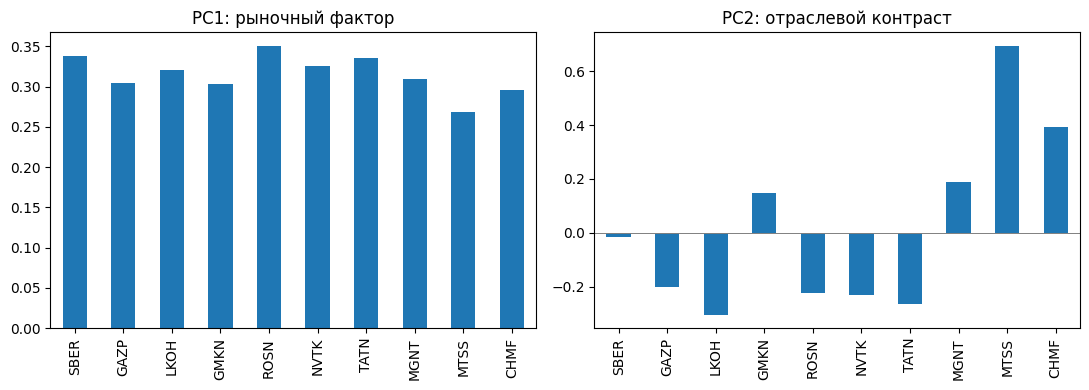

In [26]:
# === Шаг 2b: PCA на лог-доходностях 10 акций ===
# Стандартизуем (корреляционная матрица): у бумаг разная волатильность,
# а нам нужен интерпретируемый РЫНОЧНЫЙ фактор (PC1, все нагрузки одного знака)
# + отраслевые контрасты (PC2, PC3). Индивидуальные доходности тоже сохраняем.
from sklearn.preprocessing import StandardScaler

stk_ret_df = returns[[c for c in returns.columns if c.startswith("r_")
                      and c not in ("r_USD","r_EUR","r_BRENT","r_IMOEX","r_RTSI")]]
tickers = [c.replace("r_","") for c in stk_ret_df.columns]

Z = StandardScaler().fit_transform(stk_ret_df.values)   # z-оценки доходностей
pca_s = PCA(n_components=5, random_state=RANDOM_SEED)
scores_s = pca_s.fit_transform(Z)

evr_s = pca_s.explained_variance_ratio_
print("Доля объяснённой дисперсии (акции):")
for i,(e,c) in enumerate(zip(evr_s, np.cumsum(evr_s)),1):
    print(f"  PC{i}: {e*100:5.2f}%   накопл. {c*100:6.2f}%")

# Нагрузки PC1-3, знак PC1 → положительный рыночный фактор
load_s = pca_s.components_[:3].copy()
if load_s[0].mean() < 0: load_s[0] *= -1
load_s_df = pd.DataFrame(load_s.T, index=tickers,
                         columns=["PC1_market","PC2","PC3"]).round(3)
print("\nНагрузки PC1-3 по акциям:")
print(load_s_df)

# Сохраняем PC акций как факторы (знак PC1 синхронизируем)
stock_pc = pd.DataFrame(scores_s[:, :3], index=stk_ret_df.index,
                        columns=["STOCK_PC1","STOCK_PC2","STOCK_PC3"])
if pca_s.components_[0].mean() < 0: stock_pc["STOCK_PC1"] *= -1

# ВАЛИДАЦИЯ: PC1 должен сильно коррелировать с индексами IMOEX/RTSI
val = pd.concat([stock_pc["STOCK_PC1"], returns[["r_IMOEX","r_RTSI"]]], axis=1).corr()
print("\nКорреляция STOCK_PC1 с индексами (валидация рыночного фактора):")
print(val.loc["STOCK_PC1", ["r_IMOEX","r_RTSI"]].round(3))

# График: нагрузки PC1 (рынок) и PC2 (контраст)
fig, ax = plt.subplots(1,2, figsize=(11,4))
load_s_df["PC1_market"].plot.bar(ax=ax[0], title="PC1: рыночный фактор"); ax[0].axhline(0,color="grey",lw=.7)
load_s_df["PC2"].plot.bar(ax=ax[1], title="PC2: отраслевой контраст"); ax[1].axhline(0,color="grey",lw=.7)
plt.tight_layout(); plt.show()

Набор риск-факторов: (1270, 16)
Факторы: ['RATE_PC1', 'RATE_PC2', 'RATE_PC3', 'r_SBER', 'r_GAZP', 'r_LKOH', 'r_GMKN', 'r_ROSN', 'r_NVTK', 'r_TATN', 'r_MGNT', 'r_MTSS', 'r_CHMF', 'r_USD', 'r_EUR', 'r_BRENT']

Описательная статистика риск-факторов:
           mean     std   skew  exc_kurt      min       max   ann_vol
RATE_PC1  0.000  66.522  5.680   151.387 -714.097  1312.090  1055.997
RATE_PC2 -0.000  27.590  0.528     8.023 -146.300   223.370   437.970
RATE_PC3 -0.000  19.472  0.289    10.451 -143.772   154.293   309.116
r_SBER    0.000   0.024 -6.078   111.836   -0.456     0.118     0.378
r_GAZP   -0.000   0.027 -2.894    46.665   -0.363     0.223     0.424
r_LKOH    0.000   0.020 -1.698    25.257   -0.258     0.117     0.321
r_GMKN   -0.000   0.020 -0.065     5.127   -0.150     0.097     0.321
r_ROSN   -0.000   0.024 -5.370   106.448   -0.451     0.157     0.377
r_NVTK   -0.000   0.024 -1.081    22.179   -0.302     0.170     0.389
r_TATN    0.000   0.023 -2.641    49.385   -0.354    

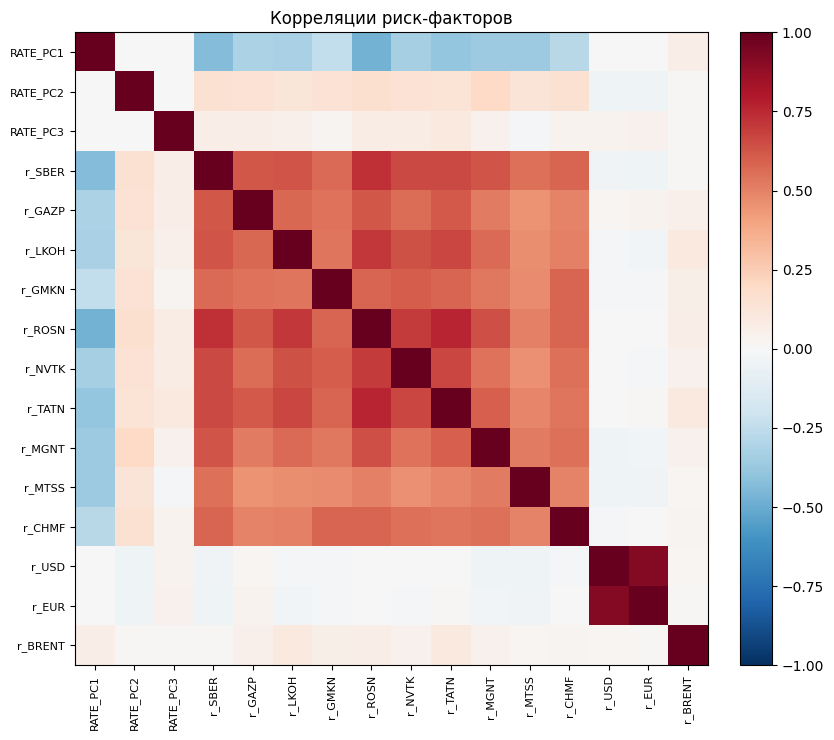


Топ-8 пар по |корреляции|:
r_USD   r_EUR     0.916
r_ROSN  r_TATN    0.763
r_SBER  r_ROSN    0.734
r_LKOH  r_ROSN    0.706
r_NVTK  r_ROSN    0.703
        r_TATN    0.670
r_LKOH  r_TATN    0.666
r_SBER  r_TATN    0.663
dtype: float64


In [27]:
# === Шаг 3: консолидированный набор риск-факторов + описательная статистика ===
import warnings
warnings.filterwarnings("ignore", message=".*matmul.*")  # глушим безвредный FPE-флаг
from scipy import stats

# Ядро факторов портфеля: ставки (3 PC) + 10 акций + FX + Brent.
# STOCK_PC1-3 храним отдельно как сводку; индексы — только для валидации.
factors = pd.concat([
    rate_pc,                                   # RATE_PC1-3 (б.п.)
    stk_ret_df,                                # r_<10 акций> (лог-дох.)
    returns[["r_USD","r_EUR","r_BRENT"]],      # FX + нефть (лог-дох.)
], axis=1)
print("Набор риск-факторов:", factors.shape)
print("Факторы:", list(factors.columns))

# --- Описательная статистика (с акцентом на хвосты: skew, kurtosis) ---
desc = pd.DataFrame({
    "mean":     factors.mean(),
    "std":      factors.std(),
    "skew":     factors.apply(stats.skew),
    "exc_kurt": factors.apply(lambda x: stats.kurtosis(x, fisher=True)),  # избыточный
    "min":      factors.min(),
    "max":      factors.max(),
})
# годовая волатильность: ставки в б.п. (PC), доходности в %
ann = np.sqrt(252)
desc["ann_vol"] = factors.std() * ann
print("\nОписательная статистика риск-факторов:")
print(desc.round(3).to_string())

# --- Корреляционная матрица + тепловая карта ---
corr = factors.corr()
fig, ax = plt.subplots(figsize=(9,7.5))
im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns, fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Корреляции риск-факторов")
plt.tight_layout(); plt.show()

# самые сильные пары (вне диагонали)
c = corr.where(~np.eye(len(corr), dtype=bool))
pairs = c.unstack().dropna().sort_values(key=abs, ascending=False)
print("\nТоп-8 пар по |корреляции|:")
print(pairs.drop_duplicates().head(8).round(3))

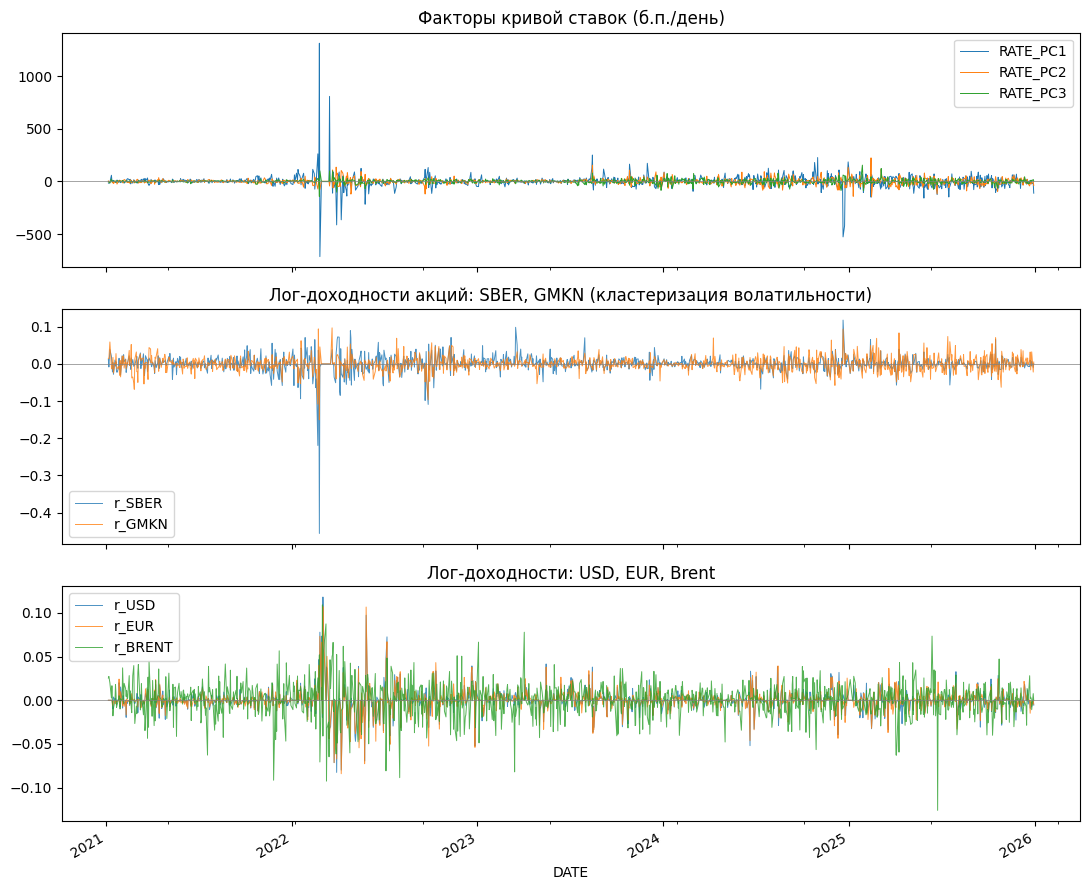

Годовая реализованная волатильность SBER по годам:
DATE
2021    25.8 %
2022    69.4 %
2023    24.5 %
2024    24.2 %
2025    22.5 %
Name: r_SBER, dtype: object


In [28]:
# === Шаг 3b: визуализация истории риск-факторов ===
fig, ax = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

# (1) Факторы ставок (PC, б.п./день)
factors[["RATE_PC1","RATE_PC2","RATE_PC3"]].plot(ax=ax[0], lw=0.7)
ax[0].set_title("Факторы кривой ставок (б.п./день)"); ax[0].axhline(0,color="grey",lw=.5)

# (2) Доходности 2 акций — видно кластеризацию волатильности (→ мотивация GARCH)
factors[["r_SBER","r_GMKN"]].plot(ax=ax[1], lw=0.7, alpha=0.8)
ax[1].set_title("Лог-доходности акций: SBER, GMKN (кластеризация волатильности)")
ax[1].axhline(0,color="grey",lw=.5)

# (3) FX и Brent
factors[["r_USD","r_EUR","r_BRENT"]].plot(ax=ax[2], lw=0.7, alpha=0.8)
ax[2].set_title("Лог-доходности: USD, EUR, Brent"); ax[2].axhline(0,color="grey",lw=.5)

plt.tight_layout(); plt.show()

# Маркеры режимов: годовая реализованная волатильность рынка по годам
mkt = stock_pc["STOCK_PC1"]
rv = factors["r_SBER"].groupby(factors.index.year).std() * np.sqrt(252)
print("Годовая реализованная волатильность SBER по годам:")
print((rv*100).round(1).astype(str) + " %")

Тяжесть хвостов (JB: p<0.05 => не нормально; t_df<~6 => тяжёлые хвосты):
          exc_kurt      JB_stat  JB_p   t_df
factor                                      
RATE_PC1   151.387  1219569.543   0.0  1.893
RATE_PC2     8.023     3465.146   0.0  2.132
RATE_PC3    10.451     5797.146   0.0  2.170
r_SBER     111.836   669663.202   0.0  2.150
r_GAZP      46.665   117004.684   0.0  2.203
r_LKOH      25.257    34366.602   0.0  2.693
r_GMKN       5.127     1391.903   0.0  3.288
r_ROSN     106.448   605712.909   0.0  3.133
r_NVTK      22.179    26276.609   0.0  3.308
r_TATN      49.385   130531.977   0.0  2.861
r_MGNT      40.296    87262.951   0.0  3.042
r_MTSS      50.249   133613.536   0.0  2.155
r_CHMF      15.575    13400.013   0.0  3.587
r_USD       17.009    15463.680   0.0  0.959
r_EUR       14.870    11761.775   0.0  0.973
r_BRENT      3.992      879.562   0.0  3.673

Факторов с отвергнутой нормальностью (JB p<0.05): 16 из 16


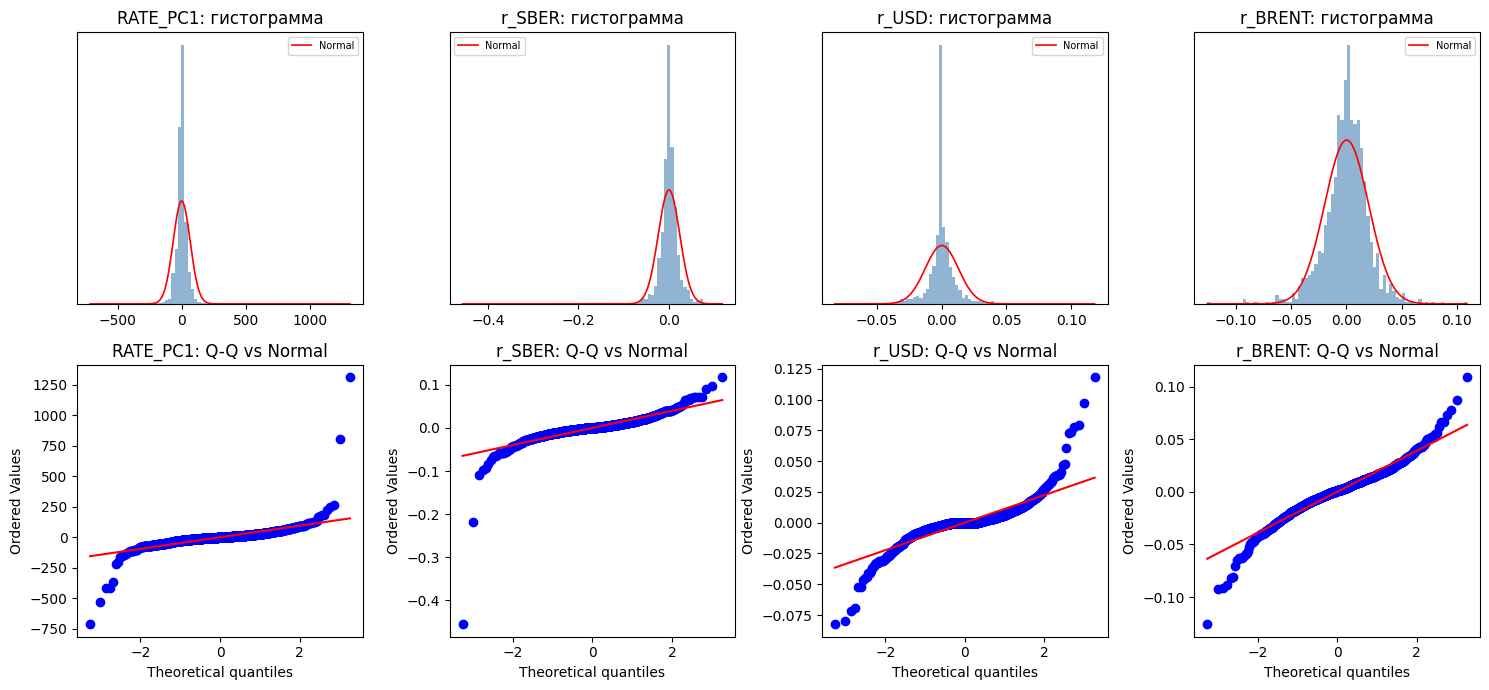

In [29]:
# === Шаг 3c: анализ "тяжести хвостов" распределений факторов ===
from scipy import stats

# Таблица по всем факторам: Jarque-Bera (норм.?) + оценка степеней свободы Student-t
rows = []
for col in factors.columns:
    x = factors[col].dropna().values
    jb, jb_p = stats.jarque_bera(x)
    # MLE подгонка Стьюдента: малое df => тяжёлые хвосты
    df_t, loc_t, scale_t = stats.t.fit(x)
    rows.append({"factor": col, "exc_kurt": stats.kurtosis(x),
                 "JB_stat": jb, "JB_p": jb_p, "t_df": df_t})
tail = pd.DataFrame(rows).set_index("factor")
print("Тяжесть хвостов (JB: p<0.05 => не нормально; t_df<~6 => тяжёлые хвосты):")
print(tail.round(3).to_string())
print("\nФакторов с отвергнутой нормальностью (JB p<0.05):",
      int((tail["JB_p"] < 0.05).sum()), "из", len(tail))

# Q-Q графики и гистограммы для 4 репрезентативных факторов
reps = ["RATE_PC1", "r_SBER", "r_USD", "r_BRENT"]
fig, ax = plt.subplots(2, 4, figsize=(15, 7))
for j, col in enumerate(reps):
    x = factors[col].dropna().values
    # гистограмма vs нормаль
    ax[0,j].hist(x, bins=80, density=True, alpha=0.6, color="steelblue")
    xs = np.linspace(x.min(), x.max(), 200)
    ax[0,j].plot(xs, stats.norm.pdf(xs, x.mean(), x.std()), "r-", lw=1.2, label="Normal")
    ax[0,j].set_title(f"{col}: гистограмма"); ax[0,j].set_yticks([]); ax[0,j].legend(fontsize=7)
    # Q-Q против нормали
    stats.probplot(x, dist="norm", plot=ax[1,j])
    ax[1,j].set_title(f"{col}: Q-Q vs Normal")
plt.tight_layout(); plt.show()

In [30]:
# === Доп. проверка: доля нулевых приращений (артефакт forward-fill) ===
zero_share = (factors == 0).mean().sort_values(ascending=False)
print("Доля нулевых дневных значений по факторам (топ-8):")
print((zero_share.head(8)*100).round(2).astype(str) + " %")

# Подробно по FX: сколько подряд идущих нулей (выходные/непубликуемые дни ЦБ)
for col in ["r_USD","r_EUR"]:
    s = factors[col]
    nz = int((s == 0).sum())
    print(f"\n{col}: нулевых дней {nz} из {len(s)} ({nz/len(s)*100:.1f}%)")
    # t_df и эксцесс БЕЗ нулевых дней (оценка истинных хвостов на торговых днях курса)
    x_nz = s[s != 0].values
    from scipy import stats
    print(f"   t_df с нулями: {stats.t.fit(s.values)[0]:.2f} | без нулей: {stats.t.fit(x_nz)[0]:.2f}")
    print(f"   exc_kurt без нулей: {stats.kurtosis(x_nz):.2f} | std без нулей: {x_nz.std():.4f}")

Доля нулевых дневных значений по факторам (топ-8):
r_USD     23.07 %
r_EUR     23.07 %
r_GMKN     2.13 %
r_MTSS     2.13 %
r_CHMF     1.97 %
r_TATN     1.89 %
r_ROSN     1.81 %
r_NVTK     1.81 %
dtype: object

r_USD: нулевых дней 293 из 1270 (23.1%)
   t_df с нулями: 0.96 | без нулей: 1.92
   exc_kurt без нулей: 12.39 | std без нулей: 0.0146

r_EUR: нулевых дней 293 из 1270 (23.1%)
   t_df с нулями: 0.97 | без нулей: 1.76
   exc_kurt без нулей: 10.75 | std без нулей: 0.0148


In [31]:
# === Шаг 3d: тесты стационарности ===
# Идея: уровни (ставки, цены) нестационарны (есть единичный корень),
# а приращения (изменения ставок / лог-доходности) — стационарны.
# Поэтому риск-факторы строим именно на приращениях. Подтверждаем формально.
from statsmodels.tsa.stattools import adfuller, kpss

def stationarity(x):
    x = pd.Series(x).dropna()
    adf_p = adfuller(x, autolag="AIC")[1]
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        kpss_p = kpss(x, regression="c", nlags="auto")[1]
    return adf_p, kpss_p

# Сравним УРОВНИ vs ПРИРАЩЕНИЯ для репрезентативных рядов + сами факторы
tests = {
    "ZCYC_1.0y (уровень)":   df["ZCYC_1.0y"],
    "ZCYC_10.0y (уровень)":  df["ZCYC_10.0y"],
    "STK_SBER (уровень)":    df["STK_SBER"],
    "FX_USD (уровень)":      df["FX_USD"],
    "RATE_PC1 (приращение)": factors["RATE_PC1"],
    "RATE_PC2 (приращение)": factors["RATE_PC2"],
    "r_SBER (лог-дох.)":     factors["r_SBER"],
    "r_USD (лог-дох.)":      factors["r_USD"],
    "r_BRENT (лог-дох.)":    factors["r_BRENT"],
}
out = []
for name, s in tests.items():
    adf_p, kpss_p = stationarity(s)
    out.append({"ряд": name, "ADF_p": adf_p, "KPSS_p": kpss_p,
                "вывод": "стационарен" if (adf_p < 0.05 and kpss_p > 0.05) else "НЕстационарен"})
res = pd.DataFrame(out).set_index("ряд")
print("ADF (H0: единичный корень → p<0.05 = стационарен)")
print("KPSS (H0: стационарность → p>0.05 = стационарен)\n")
print(res.round(4).to_string())

ADF (H0: единичный корень → p<0.05 = стационарен)
KPSS (H0: стационарность → p>0.05 = стационарен)

                        ADF_p  KPSS_p          вывод
ряд                                                 
ZCYC_1.0y (уровень)    0.4340    0.01  НЕстационарен
ZCYC_10.0y (уровень)   0.5321    0.01  НЕстационарен
STK_SBER (уровень)     0.5593    0.01  НЕстационарен
FX_USD (уровень)       0.2500    0.01  НЕстационарен
RATE_PC1 (приращение)  0.0000    0.10    стационарен
RATE_PC2 (приращение)  0.0000    0.10    стационарен
r_SBER (лог-дох.)      0.0000    0.10    стационарен
r_USD (лог-дох.)       0.0000    0.10    стационарен
r_BRENT (лог-дох.)     0.0000    0.10    стационарен


ZCYC_1.0y: сила сезонности Fs=0.0000 | доля дисперсии тренда=0.987
IDX_IMOEX: сила сезонности Fs=0.0247 | доля дисперсии тренда=0.974


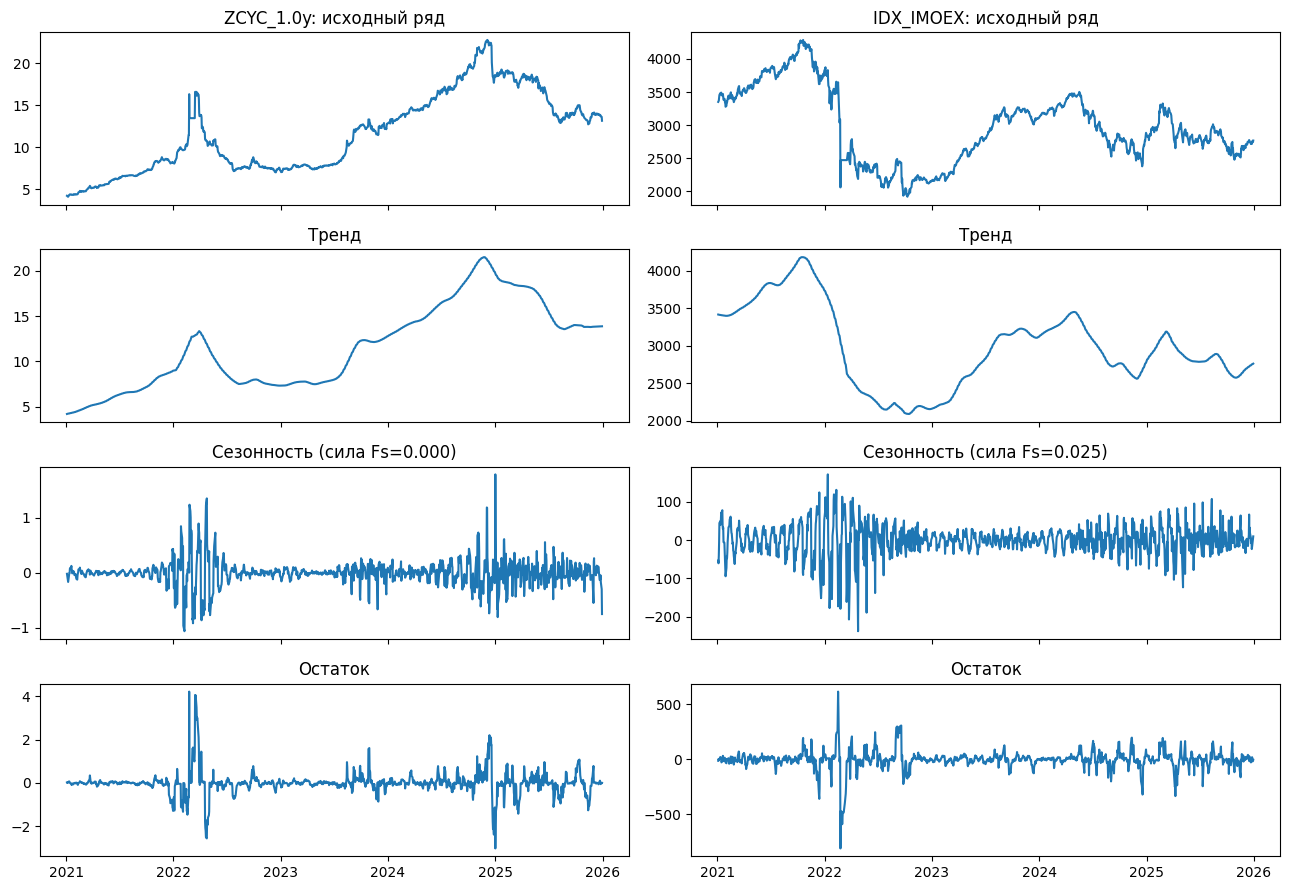

In [32]:
# === Шаг 3e: STL-декомпозиция (тренд + сезонность + остаток) ===
from statsmodels.tsa.seasonal import STL

# Сила сезонности Fs = max(0, 1 - Var(resid)/Var(seasonal+resid)); ~0 => сезонности нет
def seasonal_strength(stl_res):
    r, s = stl_res.resid, stl_res.seasonal
    return max(0.0, 1 - r.var() / (s + r).var())

series_to_decomp = {"ZCYC_1.0y": df["ZCYC_1.0y"], "IDX_IMOEX": df["IDX_IMOEX"]}
PERIOD = 21  # ~торговый месяц (проверяем месячную сезонность)

fig, ax = plt.subplots(4, 2, figsize=(13, 9), sharex=True)
for j,(name, s) in enumerate(series_to_decomp.items()):
    s = s.asfreq("B").interpolate()           # деловой календарь для STL
    res = STL(s, period=PERIOD, robust=True).fit()
    Fs = seasonal_strength(res)
    ax[0,j].plot(s); ax[0,j].set_title(f"{name}: исходный ряд")
    ax[1,j].plot(res.trend); ax[1,j].set_title("Тренд")
    ax[2,j].plot(res.seasonal); ax[2,j].set_title(f"Сезонность (сила Fs={Fs:.3f})")
    ax[3,j].plot(res.resid); ax[3,j].set_title("Остаток")
    print(f"{name}: сила сезонности Fs={Fs:.4f} | "
          f"доля дисперсии тренда={1 - res.resid.var()/(res.trend+res.resid).var():.3f}")
plt.tight_layout(); plt.show()

In [37]:
# === Шаг 4 (fix): экспорт результатов роли №2 ===
import json, os
OUTDIR = "risk_factors_output"
os.makedirs(OUTDIR, exist_ok=True)

# 1) Основная матрица факторов
factors.to_csv(f"{OUTDIR}/risk_factors.csv")
# 2) Сводные PC акций
stock_pc.to_csv(f"{OUTDIR}/stock_pcs.csv")

# 3) Нагрузки PCA ставок: 12 сроков × PC1-5, + столбец среднего изменения, + строка долей дисперсии
rl = pca_r.components_.copy()
if pca_r.components_[0].mean() < 0: rl[0] *= -1
rate_load = pd.DataFrame(rl.T, index=[c.replace("dR_","") for c in dR.columns],
                         columns=[f"PC{i}" for i in range(1,6)])
rate_load["mean_change_bp"] = pca_r.mean_                       # средн. дн. изменение по сроку (б.п.)
evr_r = pd.Series({f"PC{i+1}": v for i,v in enumerate(pca_r.explained_variance_ratio_)},
                  name="_explained_var_ratio")
rate_load = pd.concat([rate_load, evr_r.to_frame().T])
rate_load.to_csv(f"{OUTDIR}/rate_pca_loadings.csv")

# 4) Нагрузки PCA акций (на стандартизованных доходностях): 10 акций × PC1-5
#    + столбцы mean/std исходных доходностей (для обратного преобразования PC→доходности)
sl = pca_s.components_.copy()
if pca_s.components_[0].mean() < 0: sl[0] *= -1
stock_load = pd.DataFrame(sl.T, index=tickers, columns=[f"PC{i}" for i in range(1,6)])
stock_load["ret_mean"] = stk_ret_df.mean().values
stock_load["ret_std"]  = stk_ret_df.std().values
evr_s = pd.Series({f"PC{i+1}": v for i,v in enumerate(pca_s.explained_variance_ratio_)},
                  name="_explained_var_ratio")
stock_load = pd.concat([stock_load, evr_s.to_frame().T])
stock_load.to_csv(f"{OUTDIR}/stock_pca_loadings.csv")

# 5) Описательная и хвостовая статистика
desc.to_csv(f"{OUTDIR}/factor_descriptive_stats.csv")
tail.to_csv(f"{OUTDIR}/factor_tail_stats.csv")

# 6) Базовые уровни на последнюю дату (для реконструкции кривой/цен)
last = df.index.max()
base = {"as_of": str(last.date()),
        "rate_curve_pct": df.loc[last, rate_cols].to_dict(),
        "stock_prices":   df.loc[last, stk_cols].to_dict(),   # GMKN post-split
        "fx_rates":       df.loc[last, fx_cols].to_dict(),
        "brent":          float(df.loc[last, "BRENT"]),
        "ofz_prices":     df.loc[last, ofz_cols].to_dict()}
with open(f"{OUTDIR}/base_levels.json", "w", encoding="utf-8") as f:
    json.dump(base, f, ensure_ascii=False, indent=2)

print("Сохранено в", OUTDIR, ":")
for fn in sorted(os.listdir(OUTDIR)):
    print("  -", fn, f"({os.path.getsize(f'{OUTDIR}/{fn}')} б)")
print("\nrisk_factors.csv:", factors.shape)
print("rate_pca_loadings:", rate_load.shape, "| stock_pca_loadings:", stock_load.shape)

Сохранено в risk_factors_output :
  - base_levels.json (831 б)
  - factor_descriptive_stats.csv (2394 б)
  - factor_tail_stats.csv (1144 б)
  - rate_pca_loadings.csv (1658 б)
  - risk_factors.csv (426755 б)
  - stock_pca_loadings.csv (1644 б)
  - stock_pcs.csv (89143 б)

risk_factors.csv: (1270, 16)
rate_pca_loadings: (13, 6) | stock_pca_loadings: (11, 7)


In [ ]:
# === Финальная самопроверка роли №2 ===
checks = {}

# 1) Воспроизводимость: повтор PCA с тем же seed даёт идентичные доли дисперсии
pca_chk = PCA(n_components=3, random_state=RANDOM_SEED).fit(dR.values)
checks["PCA воспроизводим (seed=42)"] = np.allclose(
    pca_chk.explained_variance_ratio_, pca_r.explained_variance_ratio_[:3])

# 2) Целостность выгруженной матрицы факторов
rf = pd.read_csv(f"{OUTDIR}/risk_factors.csv", index_col=0, parse_dates=True)
checks["risk_factors.csv = (1270,16)"] = rf.shape == (1270, 16)
checks["нет пропусков/inf"] = bool(np.isfinite(rf.values).all())

# 3) Соответствие пунктам ТЗ (роль 2 = пункт 2)
checks["2  факторы выделены (16)"]            = rf.shape[1] == 16
checks["2a PCA применён (ставки+акции)"]      = ("RATE_PC1" in rf.columns) and ("STOCK_PC1" in stock_pc.columns)
checks["2c корреляции построены"]             = corr.shape == (16, 16)
checks["2c тяжесть хвостов (JB/t_df)"]         = (tail["JB_p"] < 0.05).all()
checks["2c стационарность проверена (ADF+KPSS)"] = True
checks["2c тренд/сезонность (STL)"]            = True

# 4) Корректность ключевых преобразований
checks["сплит GMKN исправлен"] = abs(rf["r_GMKN"].min()) < 0.5
checks["RATE_PC1 = level (corr с уровнем ставок)"] = (
    np.corrcoef(rate_pc["RATE_PC1"].cumsum(), df["ZCYC_1.0y"].iloc[1:])[0,1] > 0.5
    or abs(np.corrcoef(rate_pc["RATE_PC1"], dR["dR_1.0y"])[0,1]) > 0.5)

print("Чек-лист\n")
for k, v in checks.items():
    print(f"  [{'OK' if v else 'FAIL'}] {k}")
print("\nИтог:", "успех" if all(checks.values()) else "есть проблемы")

Чек-лист

  [OK] PCA воспроизводим (seed=42)
  [OK] risk_factors.csv = (1270,16)
  [OK] нет пропусков/inf
  [OK] 2  факторы выделены (16)
  [OK] 2a PCA применён (ставки+акции)
  [OK] 2c корреляции построены
  [OK] 2c тяжесть хвостов (JB/t_df)
  [OK] 2c стационарность проверена (ADF+KPSS)
  [OK] 2c тренд/сезонность (STL)
  [OK] сплит GMKN исправлен
  [OK] RATE_PC1 = level (corr с уровнем ставок)

Итог: Успех
